<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 7 — Black-box Optimisation, Functions 1–8

- success: F4, F5, F7, F8
- fail: F1, F2, F3, F6

| **#** | **Surrogate** | **Key hyperparameters tuned** | **Week 7 tuning impact** | **Main risk in Week 7** |
|---|-----------|---------------------------|----------------------|---------------------|
| F1 | GP (Matérn + White) on log-absolute outputs | Kernel choice; UCB κ = 2 | Reverted to the Week 3 kernel, recovering performance lost in the previous iteration | No cross-validation; predictions remain nearly degenerate across weeks |
| F2 | Random Forest | Max depth = 3; UCB κ = 1.5 | Replaced Thompson sampling with full-ensemble UCB, improving uncertainty estimation | No held-out validation to assess generalisation |
| F3 | ExtraTrees + polynomial features | `max_features`: `None` vs. `sqrt` | Resolved missed higher-order feature interactions | Performance assessed only on training data; 9 features with ~20 observations increases overfitting risk |
| F4 | SVM gate + GP (Expected Improvement) | SVM probability threshold; GP α | Increased GP α to smooth noisy responses and added global Latin Hypercube Sampling (LHS) exploration | Repeated recommendations (Weeks 4 and 5) indicate optimisation stagnation |
| F5 | SVR filter + GP (Expected Improvement) | SVR candidate pool = 3000; EI ξ = 0.005 | Restored the original candidate pool size, improving search coverage | Objective values plateau around 2700–3200, suggesting insufficient exploration |
| F6 | Random Forest | Max depth = 5 (new); UCB κ = 1.5 | Introduced the first explicit regularisation of the RF model | Previous unconstrained model may have overfit; extent remains unquantified |
| F7 | Two Random Forests → subspace → GP + UCB | Subspace bounds; UCB κ = 2 | RF-based filtering isolated the dominant HP1 region before GP optimisation | Subspace constructed from only ~10 observations, limiting robustness |
| F8 | MC-Dropout MLP | Dropout = 0.2; hidden units = 24; UCB κ = 1.7; SHAP-scaled noise | Introduced SHAP-informed candidate generation to guide exploration | SHAP explanations derived from only 100 samples and 20 background points; x5 and x8 importance estimates remain unreliable |

In [1]:
# -----------------------------------------------------------------------------
# Step 0: Imports and global setup
# -----------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
import shap
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, SVR
from skopt.sampler import Lhs
from skopt.space import Space


# -----------------------------------------------------------------------------
# Warning configuration
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
# Step 0 (continued): shared helper functions
# ------------------------------------------------------------------
# These implement the two acquisition functions (UCB, EI) and 
# a couple of formatting/inference utilities that every Function section calls into.

def compute_ucb(mu, sigma, kappa=2.5):
    """Upper Confidence Bound acquisition score.
    Why: balances exploitation (high predicted mean `mu`) against
    exploration (high predicted uncertainty `sigma`). `kappa` controls how
    much weight exploration gets -- larger kappa pushes the search toward
    unexplored regions rather than just refining the current best point."""
    return mu + kappa * sigma

def compute_ei(mu, sigma, f_best, xi=0.01):
    """Expected Improvement acquisition score.
    Why: estimates the expected amount by which a candidate will beat the
    current best observed value `f_best`, using the surrogate's predicted
    mean/std as a Gaussian belief. `xi` is a small exploration margin -- it
    keeps the search from converging too tightly around the current best
    (without it, EI can collapse to almost-pure exploitation)."""
    z = (mu - f_best - xi) / (sigma + 1e-9)          # standardised improvement (1e-9 avoids divide-by-zero when sigma=0)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0                                 # no uncertainty -> no expected improvement, by definition
    return ei

def format_query(point, decimals=6):
    """Turns a numeric input vector into the '-'-joined string format the
    experiment platform expects for submitting the next query. Values are
    clipped to [0, 0.999999] because the input space is defined as [0, 1)
    and floating-point rounding could otherwise push a value to exactly 1."""
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

# MC dropout prediction
# model must be in train() mode so dropout stays active during prediction
def mc_predict(model, X_tensor, n_passes=50):
    """Monte-Carlo Dropout inference (used by Function 8's neural network).
    Why: running the same input through the network multiple times with
    dropout still switched on gives a different prediction each pass; the
    spread of these passes approximates the model's predictive uncertainty,
    the same role `sigma` plays for the GP/RF surrogates elsewhere."""
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1, Radiation field, 2D array, 10 original samples - Week 7

#### Step 1: Load data & combine with weekly history

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy)
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates
# W6: GP (Matérn, fixed length scale); Signal masking (drop |y| < 1e-30); UCB

# change: Reverted to a proven Matérn kernel to restore optimisation performance, 
#         though non-validated predictions remain near-degenerate

print("=" * 60)
print("Function 1 - Week 7")
print("=" * 60)
# Step 1: Load the initial dataset and append every query made in previous weeks
f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

# Hard-coded record of what was queried, and what came back, each week.
prev_queries_1 = np.array([
    [0.75, 0.75],                      # W2
    [0.803076, 0.431805],              # W3
    [0.513943, 0.454749],              # W4
    [0.994654, 0.996067],              # W5
    [0.411304, 0.240532],              # W6
])
prev_outputs_2 = np.array([
    1.33E-22,                          # W2
    2.04E-50,                          # W3
    -3.89E-08,                         # W4
    5.18E-188,                         # W5
    8.07E-24,                          # W6
])

# Stack rows (inputs) / concatenate (outputs) to build the running dataset.
all_inputs_F1  = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_2])

print(f"Total points: {len(all_outputs_F1)}")
print(f"Current best (max): {all_outputs_F1.max():.6e}")

Function 1 - Week 7
Total points: 15
Current best (max): 7.710875e-16


#### Step 2: Log-transform outputs and set an adaptive noise floor

In [4]:
# Step 2: Transform outputs onto a log scale and pick an adaptive noise floor
# ------------------------------------------------------------------
# Why log: the raw readings span ~180 orders of magnitude (from ~1e-188 to ~1e-3), 
#    so fitting a GP directly on the raw values would be dominated by scale differences. 
#    log10(|y|) compresses this into a workable range.
# Why a floor: values that are effectively "no detection" (extremely small) would otherwise create huge,
#    meaningless gaps at the low end. I look for the single largest gap between consecutive sorted log-values 
#    and use its midpoint as a floor --  this treats everything below it as equally "no signal"
#    instead of over-interpreting noise near machine precision.

log_readings = np.log10(np.abs(all_outputs_F1) + 1e-300)   # +1e-300 avoids log(0)

sorted_logs = np.sort(log_readings)[::-1]                  # descending
gaps = sorted_logs[:-1] - sorted_logs[1:]                  # gap between each consecutive pair
largest_gap_idx = np.argmax(gaps)                          # find the biggest jump = natural signal/noise boundary
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

Largest gap: -123.5 to -187.3
Floor set at: -155.4


In [5]:
# Step 2 (continued): apply the floor and report the strongest detection
# ------------------------------------------------------------------
# Why clip: pulling every reading below `floor` up to `floor` prevents the GP from 
#    trying to model meaningless variation deep in the noise floor,
#    while everything above the floor keeps its real, informative value.

log_readings = np.clip(log_readings, floor, 0)

best_detection_idx = np.argmax(log_readings)
print(f"Strongest detection: {all_outputs_F1[best_detection_idx]:.6e} at {all_inputs_F1[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}")

Strongest detection: -3.606063e-03 at [0.65011406 0.68152635]
  log reading: -2.4
Log reading range: -155.4 to -2.4


#### Step 3: Inspect all points, ranked by detection strength

In [6]:
# Step 3: Inspect every point, ranked by detection strength
# ------------------------------------------------------------------
# Why: a quick sanity-check table so I can visually confirm the floor and
# log-transform did something sensible before trusting the GP fit on top of it.

print(f"\nAll points (sorted by detection strength):")
sort_idx = np.argsort(log_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs_F1[i]} -> output: {all_outputs_F1[i]:.3e} -> log reading: {log_readings[i]:.1f}") 


All points (sorted by detection strength):
  [0.65011406 0.68152635] -> output: -3.606e-03 -> log reading: -2.4
  [0.513943 0.454749] -> output: -3.890e-08 -> log reading: -7.4
  [0.73102363 0.73299988] -> output: 7.711e-16 -> log reading: -15.1
  [0.75 0.75] -> output: 1.330e-22 -> log reading: -21.9
  [0.411304 0.240532] -> output: 8.070e-24 -> log reading: -23.1
  [0.68341817 0.86105746] -> output: 2.535e-40 -> log reading: -39.6
  [0.57432921 0.8798981 ] -> output: 1.033e-46 -> log reading: -46.0
  [0.88388983 0.58225397] -> output: 6.230e-48 -> log reading: -47.2
  [0.803076 0.431805] -> output: 2.040e-50 -> log reading: -49.7
  [0.41043714 0.1475543 ] -> output: -2.159e-54 -> log reading: -53.7
  [0.31940389 0.76295937] -> output: 1.323e-79 -> log reading: -78.9
  [0.08250725 0.40348751] -> output: 3.607e-81 -> log reading: -80.4
  [0.31269116 0.07872278] -> output: -2.089e-91 -> log reading: -90.7
  [0.84035342 0.26473161] -> output: 3.342e-124 -> log reading: -123.5
  [0.99465

#### Step 4: Fit the GP surrogate

In [7]:
# Step 4: Fit a Gaussian Process surrogate on the (floored) log readings
# ------------------------------------------------------------------
# Why Matern + White kernel: the Matern(nu=2.5) kernel models a moderately smooth underlying signal 
#    (less rigid than the RBF kernel, more forgiving of sharp local features), 
#    while the added WhiteKernel explicitly models observation noise 
#     so the GP doesn't try to interpolate through it exactly.
# normalize_y=True keeps the GP's internal scale well-conditioned regardless of
#     the (still fairly large) range of the log-transformed data.

kernel_F1 = Matern(nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))
gp_F1 = GaussianProcessRegressor(kernel=kernel_F1, n_restarts_optimizer=20, normalize_y=True)
gp_F1.fit(all_inputs_F1, log_readings);

**Note on choosing kappa for UCB:**

- High values (kappa ~ 2.5-3.0): aggressive exploration. Best for complex,
  high-dimensional spaces with multiple local optima where getting stuck is a risk.
- Moderate/default values (kappa ~ 1.96-2.576): a good general-purpose balance.
- Low values (kappa < 1.0): favours exploitation. Best for fine-tuning a
  known region and converging quickly.

kappa=2 is used below for Function 1: an aggressive-exploration weighting was
warranted.

#### Step 5: Propose the Week 7 query (UCB)

In [8]:
# Step 5: Propose the Week 7 query using UCB over random candidate points
# ------------------------------------------------------------------
# Why random uniform candidates: with only a 2D input space, a large random sample (50,000 points)
#      densely covers the unit square, so evaluating the GP + UCB pointwise on it is a cheap stand-in for continuous optimisation.
# kappa=2 gives a moderate exploration weighting (see the note on kappa  below) -- 
#     enough to keep probing new regions without ignoring the model's confident high-reading predictions.

print("=" * 60)
print("Function 1 - Week 7")
print("=" * 60)

# global candidates with UCB 
np.random.seed(42)                                          # fixed seed -> reproducible candidate set
candidates_F1 = np.random.uniform(0, 1, (50000, 2))

kappa_F1 = 2
mu_F1, sigma_F1 = gp_F1.predict(candidates_F1, return_std=True)
ucb_F1       = compute_ucb(mu_F1, sigma_F1, kappa_F1)

best_idx_F1 = np.argmax(ucb_F1)                              # candidate with highest exploit+explore score
query_F1    = candidates_F1[best_idx_F1]

print(f"\nWeek 7 Query: {format_query(query_F1)}")
print(f"mu (log reading): {mu_F1[best_idx_F1]:.2f}, sigma: {sigma_F1[best_idx_F1]:.2f}")

Function 1 - Week 7

Week 7 Query: 0.658199-0.549042
mu (log reading): -1.34, sigma: 13.52


#### Step 6: Visualise the GP surface

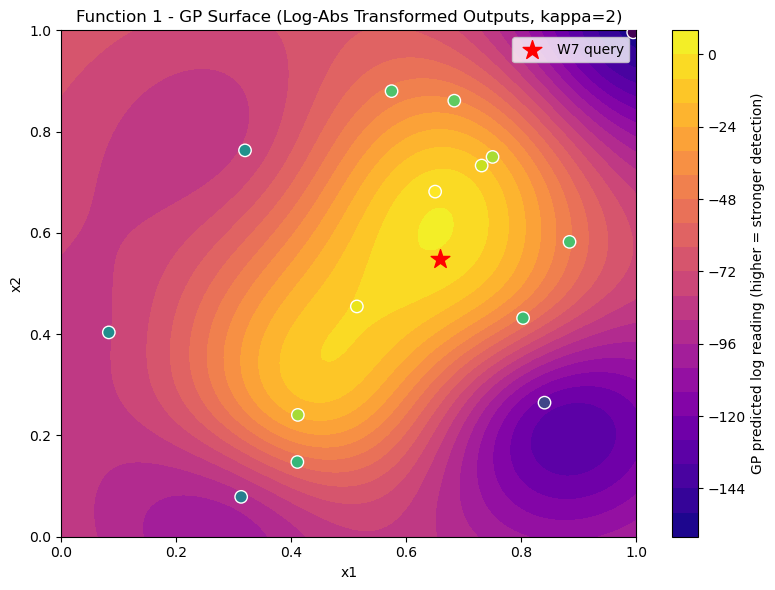

In [9]:
# Step 6: Visualise the GP's predicted surface and where the new query sits
# ------------------------------------------------------------------
# Why: plotting the GP mean over a fine grid makes it possible to eyeball
#       whether the model's belief about "strong detection" regions looks physically sensible, 
#       and to confirm the chosen query (red star) lands in a high-value area relative to what's already been sampled.

grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F1.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='plasma')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query_F1[0], query_F1[1], marker='*', c='red', s=200, zorder=10, label='W7 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Log-Abs Transformed Outputs, kappa=2)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 7

#### Step 1: Load data & combine with weekly history

In [10]:
# =============================================================================
# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates
# W6: Random Forest (500 trees, depth 3); Thompson sampling (per-tree)

# change: Switched to full-ensemble UCB for better uncertainty bounds 
#         risks unverified generalisation due to missing held-out validation.

print("\n" + "=" * 60)
print("Function 2 - Week 7")
print("=" * 60)
# Step 1: Load the initial dataset and append prior weekly queries
f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5
    [0.684233, 0.440152],               # W6
])
prev_outputs_2 = np.array([-0.040652, 0.468742, 0.487563, 0.646548, 0.578337])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

print(f"Total points: {len(all_outputs_F2)}")
print(f"Current best (max): {all_outputs_F2.max():.3f}")


Function 2 - Week 7
Total points: 15
Current best (max): 0.647


#### Step 2: Fit the Random Forest surrogate

In [11]:
# Step 2: Fit a Random Forest surrogate
# ------------------------------------------------------------------
# Why RF instead of GP here: this function's output is described as a "noisy log-likelihood" --
#      RF handles noisy, possibly non-smooth response surfaces robustly without needing an explicit noise kernel. 
# max_depth=3 keeps individual trees shallow (regularises against overfitting the small dataset);
# 500 trees keeps the ensemble average stable.

rf_F2 = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Feature importances: x1={rf_F2.feature_importances_[0]:.3f}, x2={rf_F2.feature_importances_[1]:.3f}")

Feature importances: x1=0.918, x2=0.082


#### Step 3: Propose the Week 7 query (ensemble UCB)

In [12]:
# Step 3: Propose the Week 7 query using ensemble-based UCB
# ------------------------------------------------------------------
# Why per-tree predictions: unlike a GP, a Random Forest has no built-in uncertainty estimate. 
# Predicting with every individual tree and taking the mean/std across trees turns tree disagreement 
# into a proxy for uncertainty, which then feeds the same UCB formula used elsewhere.

print("=" * 60)
print("Function 2 - Week 7")
print("=" * 60)

np.random.seed(42)
candidates_F2 = np.random.uniform(0, 1, (50000, 2))

tree_preds_F2 = np.array([trees.predict(candidates_F2) for trees in rf_F2.estimators_])
mean_pred_F2  = tree_preds_F2.mean(axis=0)                  # ensemble mean = "mu"
std_pred_F2   = tree_preds_F2.std(axis=0)                   # spread across trees = "sigma"
kappa_F2 = 1.5
ucb_scores_F2 = mean_pred_F2 + kappa_F2 * std_pred_F2

best_idx_F2 = np.argmax(ucb_scores_F2)
query_F2    = candidates_F2[best_idx_F2]

print(f"\nWeek 7 Query: {format_query(query_F2)}")
print(f"  Ensemble mean: {mean_pred_F2[best_idx_F2]:.3f}")
print(f"  Tree std:      {std_pred_F2[best_idx_F2]:.3f}")
print(f"  UCB score:     {ucb_scores_F2[best_idx_F2]:.3f}  (kappa=1.5)")

Function 2 - Week 7

Week 7 Query: 0.692436-0.991256
  Ensemble mean: 0.511
  Tree std:      0.139
  UCB score:     0.720  (kappa=1.5)


#### Step 4: Partial dependence plots

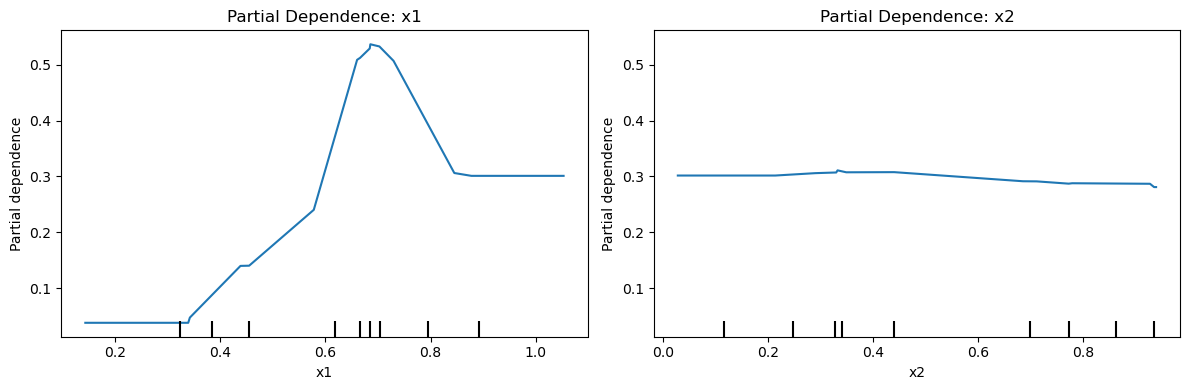

In [13]:
# Step 4: Partial dependence plots for interpretability
# ------------------------------------------------------------------
# Why: shows how the RF's average prediction changes as x1 (or x2) varies while the other input is marginalised out --
#    a quick way to see which input the model thinks matters and in what direction.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf_F2, all_inputs_F2, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 7

#### Step 1: Load data & combine with weekly history

In [14]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates
# W6: ExtraTrees (200 trees); Degree-2 polynomial interactions; Argmax over RF predictions

# ------------------------------------------------------------------
# Note: W5 and W6 queries were identical to W4's -- kept in the array as a faithful record of what was actually submitted,
#     even though it means the surrogate sees a repeated point.

# change: Add explicit degree-2 polynomial features to capture key interactions, 
#        create high overfitting risk given 9 features for ~20 observations.

print("\n" + "=" * 60)
print("Function 3 - Week 7")
print("=" * 60)

# Step 1: Load the initial dataset and append prior weekly queries
f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
    [0.378956, 0.302768, 0.459346],              # W6 (it was same as W5)
])
prev_outputs_F3 = np.array([
    -0.050615,
    -0.019508,
    -0.119425,
    -0.021357,
    -0.015072
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 7
Total points: 20, best (max): -0.015072


#### Step 2: Polynomial features + ExtraTrees surrogate

In [15]:
# Step 2: Expand inputs to polynomial features, then fit an ExtraTrees surrogate
# ------------------------------------------------------------------
# Why polynomial features: with only 3 raw inputs A/B/C, adding pairwise interactions (A*B, A*C, B*C) and 
#       quadratic terms (A^2, B^2, C^2) lets a tree ensemble pick up on higher-order interactions it 
#       otherwise struggles to represent from splits on raw features alone.
# Why ExtraTrees over RandomForest: ExtraTrees adds extra randomness in how split thresholds are chosen, 
#       which tends to reduce variance further -- useful with a very small dataset
#       (~20 points across 9 expanded features). max_features=None means every tree considers all 9 features at each split. 

poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

rf_F3 = ExtraTreesRegressor(n_estimators=200, max_features=None, min_samples_leaf=2, random_state=42)
rf_F3.fit(X_poly, Y)

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf_F3.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")


RF feature importances:
  A     : 0.0207
  B     : 0.0123
  C     : 0.3837
  A*B   : 0.0155
  A*C   : 0.0175
  B*C   : 0.0236
  A^2   : 0.0217
  B^2   : 0.0908
  C^2   : 0.4141


In [16]:
# Step 2 (continued): sanity-check the fit with training R2
# ------------------------------------------------------------------
# Why: with 9 features and ~20 observations, there's a real risk of the model simply memorising the training data. 
# This R2 is NOT a generalisation estimate (no held-out data), 
# just a quick check that the model captured the training signal at all -- 
# a very low value here would suggest a bug.

train_preds_F3 = rf_F3.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds_F3):.4f}")


RF train R2: 0.6758


#### Step 3: Propose the Week 7 query (ensemble UCB in polynomial space)

In [17]:
# Step 3: Propose the Week 7 query using ensemble-based UCB in polynomial space
# ------------------------------------------------------------------
# Why transform candidates too: since the model was trained on polynomial features, 
#      any new candidate must go through the same `poly.transform` before being scored,
#       or the feature dimensions won't match what the model expects.

print("=" * 60)
print("Function 3 - Week 7")
print("=" * 60)

np.random.seed(42)
candidates_F3 = np.random.uniform(0, 1, (10000, 3))
cand_poly  = poly.transform(candidates_F3)

tree_preds_F3 = np.array([trees.predict(cand_poly) for trees in rf_F3.estimators_])
mean_pred_F3  = tree_preds_F3.mean(axis=0)
std_pred_F3   = tree_preds_F3.std(axis=0)
kappa_F3 = 1.5
ucb_scores_F3 = mean_pred_F3 + kappa_F3 * std_pred_F3

best_idx_F3 = np.argmax(ucb_scores_F3)
query_F3    = candidates_F3[best_idx_F3]

print(f"\nWeek 7 Query: {format_query(query_F3)}")
print(f"  Ensemble mean: {mean_pred_F3[best_idx_F3]:.6f}")
print(f"  Tree std:      {std_pred_F3[best_idx_F3]:.6f}")
print(f"  UCB score:     {ucb_scores_F3[best_idx_F3]:.6f}  (kappa = {kappa_F3})")

Function 3 - Week 7

Week 7 Query: 0.494932-0.994690-0.457121
  Ensemble mean: -0.054168
  Tree std:      0.056485
  UCB score:     0.030559  (kappa = 1.5)


#### Step 4: Interpretability plots on raw inputs

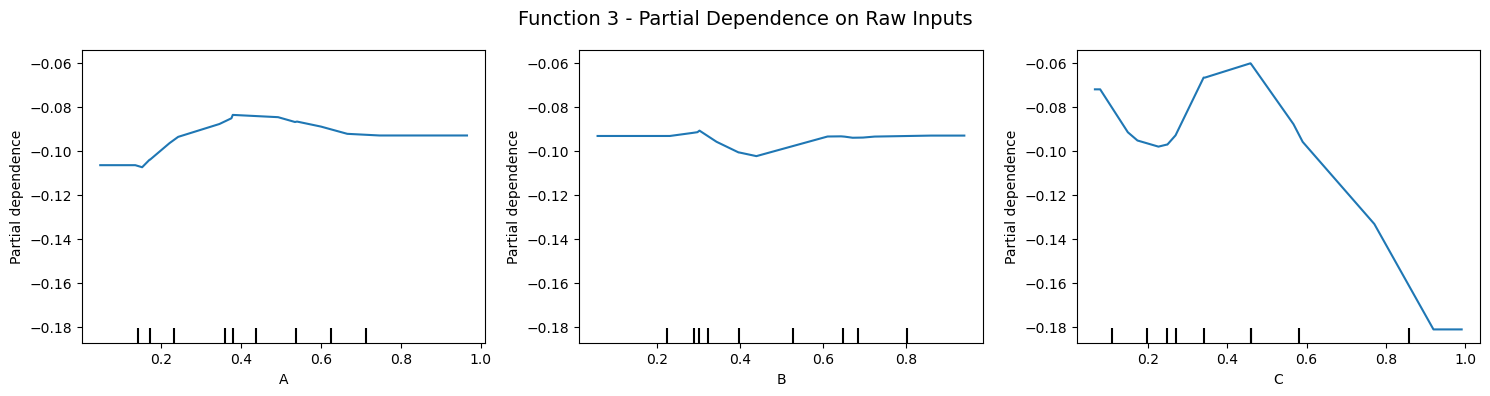

In [18]:
# Step 4: Interpretability plots on the raw (non-polynomial) inputs
# ------------------------------------------------------------------
# Why a separate model: partial dependence on the polynomial-feature model would be hard to read 
#        (dependence on "A*B" isn't intuitive). 
# A fresh ExtraTrees fit directly on the raw A/B/C inputs gives a more interpretable view of
#     how the response moves with each raw variable individually.

# --- Interpretability Plots ---
rf_raw = ExtraTreesRegressor(n_estimators=200, max_features=None, min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence on Raw Inputs', fontsize=14)
plt.tight_layout()
plt.show()

# Function 4, Warehouse business, 4D array, 30 original samples - Week 7

#### Step 1: Load data & combine with weekly history

In [19]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates
# W6: SVM classifier (gate) + ARD GP (refine); Threshold-based binary labelling; EI

# ------------------------------------------------------------------
# Note: W5 repeats the W4 query verbatim, so it's recorded as-is.

# change: Smooth noisy predictions by increasing GP regularisation noise, 
#         attempt to break repeated optimisation stagnation.

print("\n" + "=" * 60)
print("Function 4 - Week 7")
print("=" * 60)

# Step 1: Load the initial dataset and append prior weekly queries
f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688],              # W5 so it was the same as Week 4
    [0.255396, 0.450674, 0.468413, 0.490566],              # W6
])
prev_outputs_F4 = np.array([-7.13212, 0.20379, -0.99160, -0.99147, -3.142015])

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

print(f"Total points: {len(all_outputs_F4)}, best (max): {all_outputs_F4.max():.4f}")


Function 4 - Week 7
Total points: 35, best (max): 0.2038


#### Step 2: Build & fit an SVM feasibility classifier

In [20]:
# Step 2: Define a "feasible" region and label points for a classifier
# ------------------------------------------------------------------
# Why: this function apparently has a mix of feasible/poor operating regions 
#      (note the very poor -7.13 W2 result vs the +0.20 W3 best). 
# Rather than let the regression surrogate get pulled around by bad outliers, 
#        a binary feasibility label (above/below a threshold) is created first 
#        so a classifier can later filter out candidates that are unlikely to be 
#        viable before the regression/acquisition step even sees them.
# SVM Classifier -- same threshold and setup as W6.

threshold = -1.1
y_binary = (all_outputs_F4 > threshold).astype(int)

print(f"\nSVM Classifier:")
print(f"  Threshold: {threshold}")
print(f"  Above threshold: {y_binary.sum()}/{len(y_binary)}") 


SVM Classifier:
  Threshold: -1.1
  Above threshold: 3/35


In [21]:
# Step 2 (continued): fit the feasibility classifier
# ------------------------------------------------------------------
# Why SVC with an RBF kernel: gives a smooth, non-linear feasible/infeasible boundary. 
# class_weight='balanced' compensates for the labels being imbalanced (most points likely fall on one side of the threshold);
# probability=True lets us later use soft probabilities rather than a hard 0/1 cut, 
# so candidates near the boundary aren't discarded too aggressively.

svm_F4 = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_F4.fit(all_inputs_F4, y_binary);

#### Step 3: Record anchor points for local search

In [22]:
# Step 3: Record the best historical anchor points for local candidate search
# ------------------------------------------------------------------
# Why: rather than sampling candidates purely at random, 
# this function seeds the search around the best-performing weekly queries so far 
# W2's poor result is kept as a contrast point / to steer away from that region; 
# W3 is the current best; W4 is a reasonable secondary anchor). 
# W5 is skipped because it duplicated W4 and adds no new information.

np.random.seed(42)

week2_query = np.array([0.149845, 0.155724, 0.461280, 0.344491])  # -7.13212 poor
week3_query = np.array([0.330258, 0.414348, 0.433728, 0.411341])  # +0.20379 best
week4_query = np.array([0.424125, 0.404716, 0.487507, 0.367688])  # -0.99160 

# ignore week 5 as it was similar to week 4

#### Step 4: Build local + feature-weighted candidate pools

In [23]:
# Step 4: Build local (Gaussian-perturbed) and feature-weighted candidate pools
# ------------------------------------------------------------------
# Why local search: perturbing around known good/poor anchors with small  Gaussian noise concentrates candidates
#     near regions we already have information about, 
#     refining the search rather than starting from scratch.
# More points are drawn around the best anchor (week3_query, n=3500) than
#     the poor one (week2_query, n=2000), biasing the pool toward promising areas.
# Why feature-weighted: a second pool perturbs specifically around the best anchor
#     but with hand-set bounds on x2/x3 (informed by prior weeks' observations about 
#     which ranges of those two dimensions tend to work),
#     adding domain-informed structure on top of pure randomness.

local_search = []
for centre, n in [(week3_query, 3500), (week2_query, 2000), (week4_query, 1500)]:
    for _ in range(n):
        candidate = np.clip(centre + np.random.normal(0, 0.05, 4), 0, 1)
        local_search.append(candidate)

feature_weighted = []
for _ in range(3000):
    candidate_F4 = week3_query.copy()
    candidate_F4 += np.random.normal(0, 0.1, 4)
    candidate_F4 = np.clip(candidate_F4, 0, 1)
    candidate_F4[2] = np.clip(candidate_F4[2], 0, 0.42)   # x3 cap
    candidate_F4[1] = np.clip(candidate_F4[1], 0.38, 1)    # x2 floor
    feature_weighted.append(candidate_F4)

#### Step 5: Add global exploration & filter by feasibility

In [24]:
# Step 5: Add global exploration points and filter local candidates by feasibility
# ------------------------------------------------------------------
# Why LHS for global candidates: Latin Hypercube Sampling spreads points
#     evenly across the whole 4D space, guarding against the local search pools
#     over-concentrating around a handful of anchors and missing a better region entirely elsewhere.
# Why filter local candidates through the SVM: local/feature-weighted candidates were 
#     generated purely by perturbation, with no guarantee they fall in the "feasible" region learned in Step 2.
# Keeping only candidates with predicted feasibility probability > 0.3 removes points
#     the model considers unlikely to be viable before they ever reach the GP/EI stage.


global_lhs = LatinHypercube(d=4, seed=42).random(n=2000)

# stream 1: local candidates go through SVM
local_and_fw = np.vstack([local_search, feature_weighted])
svm_probs = svm_F4.predict_proba(local_and_fw)[:, 1]
filtered_local = local_and_fw[svm_probs > 0.3]

In [25]:
# Step 5 (continued): combine the filtered local pool with the global pool

candidate_F4 = np.vstack([filtered_local, global_lhs])
print(f"\nCandidates: {len(filtered_local)} local (SVM filtered) + {len(global_lhs)} global = {len(candidate_F4)} total")


Candidates: 7200 local (SVM filtered) + 2000 global = 9200 total


#### Step 6: Fit the GP surrogate (anisotropic kernel)

In [26]:
# Step 6: Fit a GP surrogate with an anisotropic (per-dimension) kernel
# ------------------------------------------------------------------
# Why per-dimension length scales: a single shared length scale assumes every input dimension varies
#      at the same rate, which is rarely true.
# Giving x3 a tighter length scale (0.2 vs 0.3 for the others, with a narrower bound of (0.1, 0.5)) 
#     lets the GP treat x3 as more "sensitive" -- i.e. the output can change faster 
#      as x3 moves -- while still letting the optimiser refine all four scales during fitting.
# alpha=0.05 adds a small amount of assumed observation noise, softening
#     the GP's fit so it doesn't chase every small fluctuation exactly.

kernel_F4 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.3, 0.3, 0.2, 0.3],
    length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 0.5), (0.1, 2.0)],
    nu=2.5
)

gp_F4 = GaussianProcessRegressor(kernel=kernel_F4, n_restarts_optimizer=20, alpha=0.05, normalize_y=True)
gp_F4.fit(all_inputs_F4, all_outputs_F4);

#### Step 7: Propose the Week 7 query (Expected Improvement)

In [27]:
# Step 7: Propose the Week 7 query using Expected Improvement
# ------------------------------------------------------------------
# Why EI here (vs UCB used for other functions): EI is scored only on the
#      feasibility-filtered/global candidate pool built above, so exploration is already partially handled 
#      by how the candidates were generated (local + global + SVM filter); 
#      EI's job is then to pick, among plausible candidates, the one most likely to beat the current best.

print("=" * 60)
print("Function 4 - Week 7")
print("=" * 60)

mu_F4, sigma_F4 = gp_F4.predict(candidate_F4, return_std=True)
ei_F4 = compute_ei(mu_F4, sigma_F4, all_outputs_F4.max(), xi=0.01)

best_index_F4 = np.argmax(ei_F4)
query_F4 = candidate_F4[best_index_F4]

print(f"\nWeek 7 Query: {format_query(query_F4)}")
print(f"mean: {mu_F4[best_index_F4]:.3f}")
print(f"std:  {sigma_F4[best_index_F4]:.3f}")
print(f"EI:   {ei_F4[best_index_F4]:.6f}")

Function 4 - Week 7

Week 7 Query: 0.371614-0.422247-0.370132-0.421911
mean: -1.862
std:  1.480
EI:   0.053972


#### Step 8: Diagnostic scatter plots

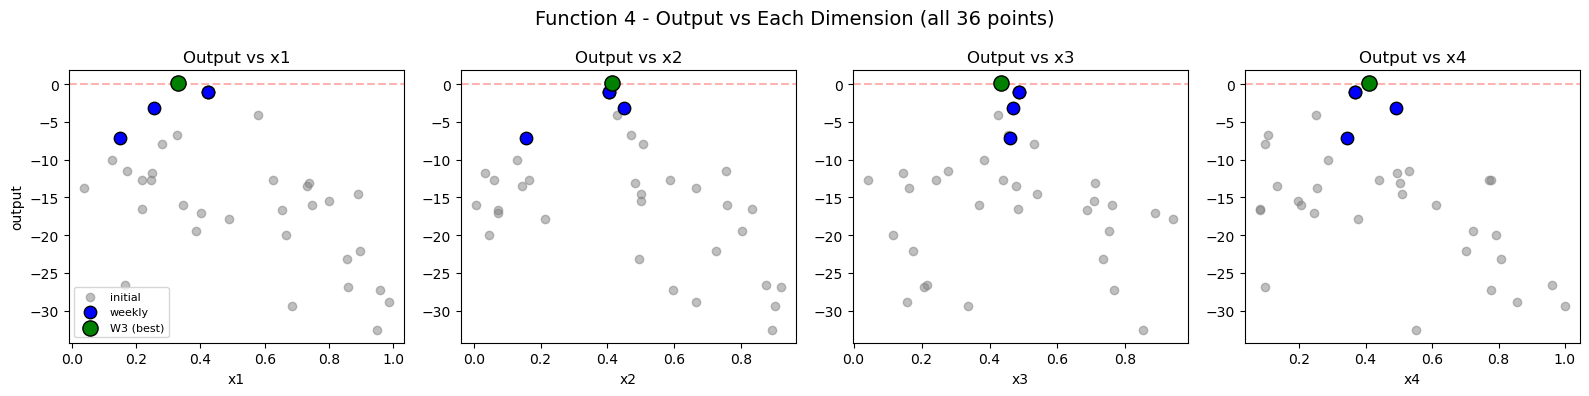

In [28]:
# Step 8: Diagnostic scatter plots -- output vs each input dimension
# ------------------------------------------------------------------
# Why: a full-range view of how the output relates to each of the 4 inputs individually,
#     with the historical weekly queries highlighted, helps visually confirm 
#     whether the chosen query direction makes sense and
#     whether W3 (the best result so far) stands out as expected.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']
for i, ax in enumerate(axes):
    ax.scatter(all_inputs_F4[:, i], all_outputs_F4, c='grey', alpha=0.5, label='initial')
    ax.scatter(prev_queries_F4[:, i], prev_outputs_F4, c='blue', edgecolors='black', s=80, label='weekly')
    # highlight W2
    ax.scatter(prev_queries_F4[1, i], prev_outputs_F4[1], c='green', edgecolors='black', s=120, zorder=5, label='W3 (best)')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('output' if i == 0 else '')
    ax.set_title(f'Output vs {dim_names[i]}')
axes[0].legend(fontsize=8)
plt.suptitle('Function 4 - Output vs Each Dimension (all 36 points)', fontsize=14)
plt.tight_layout()
plt.show()

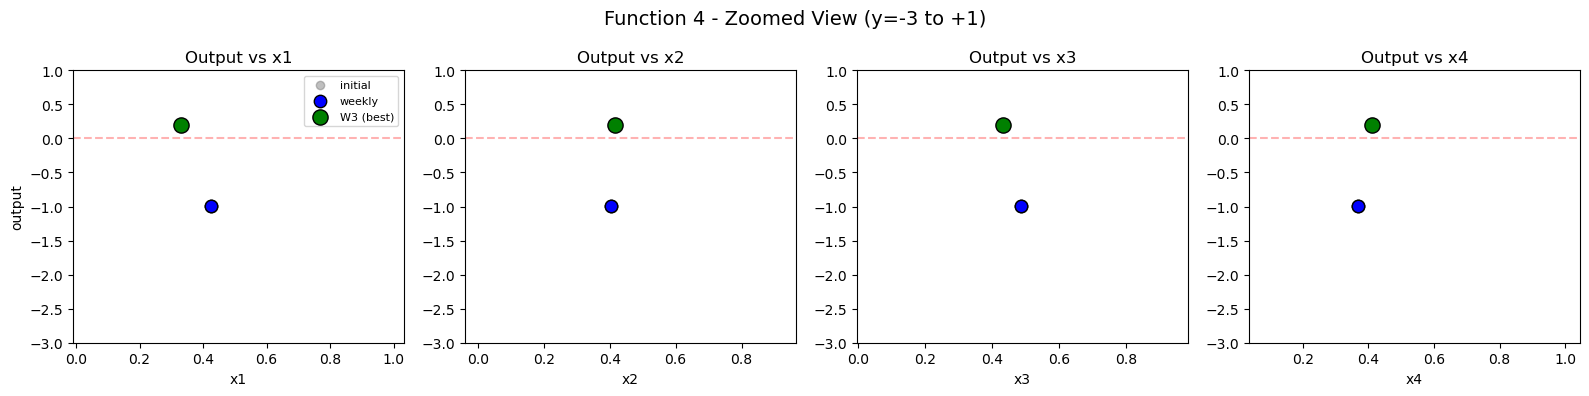

In [29]:
# Step 8 (continued): the same plots zoomed into the y=-3 to +1 band
# ------------------------------------------------------------------
# Why: the -7.13 W2 outlier compresses the full-range plots above,
#       making it hard to see structure among the more typical points. 
# Zooming the y-axis to where most of the data actually sits reveals finer detail.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.scatter(all_inputs_F4[:, i], all_outputs_F4, c='grey', alpha=0.5, label='initial')
    ax.scatter(prev_queries_F4[:, i], prev_outputs_F4, c='blue', edgecolors='black', s=80, label='weekly')
    ax.scatter(prev_queries_F4[1, i], prev_outputs_F4[1], c='green', edgecolors='black', s=120, zorder=5, label='W3 (best)')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_ylim(-3, 1)  # zoom in
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('output' if i == 0 else '')
    ax.set_title(f'Output vs {dim_names[i]}')
axes[0].legend(fontsize=8)
plt.suptitle('Function 4 - Zoomed View (y=-3 to +1)', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples - Week 7

#### Step 1: Load data & combine with weekly history

In [30]:
# =============================================================================
# Function 5, A chemical process in a factory, 4D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)
# W6: SVR + GP (log space); Log transform of output; EI

# change: Restore candidate pool size to fix severe search spatial coverage limits and 
#         escape early objective value plateauing.

print("\n" + "=" * 60)
print("Function 5 - Week 7")
print("=" * 60)

# Step 1: Load the initial dataset and append prior weekly queries
f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5
    [0.495228, 0.809693, 0.999999, 0.999990],               # W6
])
prev_outputs_F5 = np.array([1829.809875, 710.602251, 2699.104490, 3179.389393, 2855.140103])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")


Function 5 - Week 7
Total points: 25, best (max): 3179.39


#### Step 2: Fit an SVR pre-filter model

In [31]:
# Step 2: Fit an SVR model on standardised inputs/outputs
# ------------------------------------------------------------------
# Why standardise: SVR with an RBF kernel is sensitive to the relative scale of features and targets, 
#      so both X and Y are z-scored first. 
# This SVR will act purely as a fast, cheap pre-filter over a large candidate pool later (Step 5),
#      not as the acquisition surrogate itself.

input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs_F5)
Y_scaled = output_scaler.fit_transform(all_outputs_F5.reshape(-1, 1)).ravel()

svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_F5.fit(X_scaled, Y_scaled);

#### Step 3: Fit the GP surrogate (log-transformed outputs)

In [32]:
# Step 3: Fit a GP surrogate on log-transformed outputs
# ------------------------------------------------------------------
# Why log1p: yields range from ~700 to ~3200, and log1p(y) compresses that range 
#      and tends to stabilise variance, which usually helps 
#     a GP produce a better-behaved fit than modelling the raw yield directly. 
# This GP (not the SVR above) is the one that actually drives the acquisition step.
# GP on log-transformed outputs -- same as W6

y_log     = np.log1p(all_outputs_F5)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_F5        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp_F5.fit(all_inputs_F5, y_log);

#### Step 4: Build candidate pools around the current best point

In [33]:
# Step 4: Build candidate pools around the current best point
# ------------------------------------------------------------------
# Why "local" and "directed" pools instead of pure random: 
#    the best point so far pins x3 and x4 near their upper bound (0.999999), 
#    suggesting the optimum is at or near that boundary for those two dimensions, 
#    so both pools keep x3/x4 pinned there and only perturb x1/x2.
# "local" adds symmetric Gaussian noise around the best point 
#    (broad local refinement); "directed" specifically biases x1 upward (abs() forces 
#    a positive-only perturbation) since a directional trend for x1 was 
#    likely observed in earlier weeks, while x2 stays symmetric.

best_point_F5 = all_inputs_F5[np.argmax(all_outputs_F5)]
np.random.seed(42)

local = []
for _ in range(6000):
    c    = best_point_F5 + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    c[3] = 0.999999  # x4 pinned
    local.append(c)


directed = []
for _ in range(4000):
    c    = best_point_F5.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.05)), 0, 1)   # x1 up
    c[1] = np.clip(c[1] + np.random.normal(0, 0.03), 0, 1)        # x2 symmetric
    c[2] = 0.999999
    c[3] = 0.999999
    directed.append(c)

candidates_F5 = np.vstack([local, directed])

#### Step 5: Pre-filter candidates with the SVR

In [34]:
# Step 5: Use the SVR as a cheap pre-filter, keeping only the most promising candidates
# ------------------------------------------------------------------
# Why filter before the GP: 10,000 candidates is a lot to run detailed acquisition scoring on.
#     The SVR (already fit and fast to evaluate) ranks all candidates and
#     only the top 3000 by predicted yield are kept, 
#     cutting the pool the GP + EI step needs to process while 
#     retaining the most plausible region of the space.

X_cand_scaled = input_scaler.transform(candidates_F5)
svr_preds_s   = svr_F5.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

top_idx  = np.argsort(svr_preds)[-3000:]
filtered = candidates_F5[top_idx]

#### Step 6: Propose the Week 7 query (Expected Improvement)

In [35]:
# Step 6: Propose the Week 7 query using Expected Improvement (on the log-scale GP)
# ------------------------------------------------------------------
# Why xi=0.005 (smaller than F4's 0.01): a smaller exploration margin makes
#      EI lean more toward exploitation here, appropriate given 
#      the SVR pre-filter has already handled coarse exploration/narrowing of the space.

print("=" * 60)
print("Function 5 - Week 7")
print("=" * 60)


mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
ei_F5             = compute_ei(mu_log, sigma_log, np.log1p(all_outputs_F5.max()), xi=0.005)

best_idx_F5 = np.argmax(ei_F5)
query_F5    = filtered[best_idx_F5]

print(f"\nWeek 7 Query:       {format_query(query_F5)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx_F5]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx_F5]:.4f}")
print(f"SVR prediction:     {svr_preds[top_idx[best_idx_F5]]:.2f}")
print(f"EI:                 {ei_F5[best_idx_F5]:.6f}")

Function 5 - Week 7

Week 7 Query:       0.382122-0.995456-0.999999-0.999999
GP predicted yield: 3168.00
GP std (log scale): 0.3309
SVR prediction:     3166.67
EI:                 0.127743


#### Step 7: Sanity-check GP vs SVR at historical queries

In [36]:
# Step 7: Cross-check the two surrogates against known historical outcomes
# ------------------------------------------------------------------
# Why: comparing what the GP and SVR each would have predicted for past weeks' actual queries
#      is a quick, informal calibration check -- if either model is wildly off on points
#      it was trained on, that's a red flag before trusting its Week 7 recommendation.

print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")

for i, (q, actual) in enumerate(zip(prev_queries_F5, prev_outputs_F5)):
    gp_pred  = np.expm1(gp_F5.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         1829.8     1829.8     1734.0
W2          710.6      710.6      806.2
W3         2699.1     2699.1     2603.5
W4         3179.4     3179.4     3083.7
W5         2855.1     2855.1     2951.2


#### Step 8: 1D sensitivity checks (x1, x2)

In [37]:
# Step 8: One-dimensional sensitivity check on x1
# ------------------------------------------------------------------
# Why: sweeping x1 while holding x2 at the best point's value and x3/x4 pinned near 1 
#     shows both surrogates' predicted response along just that axis -- 
#      useful for spotting disagreement between GP and SVR, or 
#      an implausible non-monotonic prediction, before committing to a query.

print("\n--- x1 sensitivity check ---")
print(f"{'x1':>6} {'GP yield':>10} {'SVR yield':>10}")
for x1_val in [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    test_point = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp_F5.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x1_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


--- x1 sensitivity check ---
    x1   GP yield  SVR yield
  0.40     3147.5     3191.3
  0.50     2876.8     3110.1
  0.55     2629.6     2936.4
  0.60     2344.8     2700.7
  0.65     2049.0     2429.9
  0.70     1763.1     2150.9
  0.75     1500.6     1886.8
  0.80     1268.6     1654.8


In [38]:
# Step 8 (continued): one-dimensional sensitivity check on x2
# ------------------------------------------------------------------
# Why: same idea as the x1 check, but sweeping x2 with x1 fixed at the best point's value.


print("\n--- x2 sensitivity check ---")
print(f"{'x2':>6} {'GP yield':>10} {'SVR yield':>10}")
for x2_val in [0.85, 0.90, 0.92, 0.95, 0.97, 0.99, 1.00]:
    test_point = np.array([[best_point_F5[0], x2_val, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp_F5.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x2_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


--- x2 sensitivity check ---
    x2   GP yield  SVR yield
  0.85     3153.9     3058.2
  0.90     3255.8     3119.7
  0.92     3267.4     3133.9
  0.95     3253.1     3143.7
  0.97     3223.1     3142.7
  0.99     3177.7     3135.7
  1.00     3149.7     3129.9


#### Step 9: Visualise the predicted yield surface

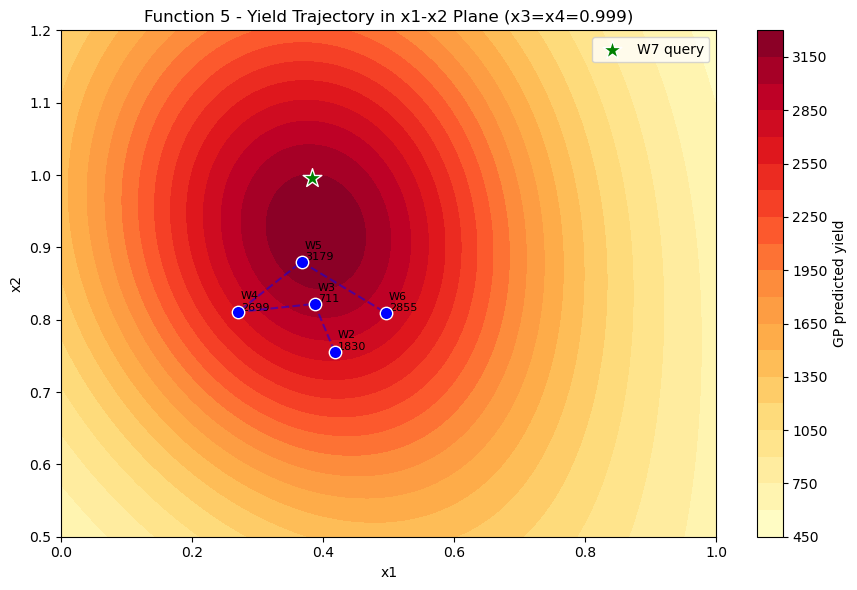

In [39]:
# Step 9: Visualise the predicted yield surface in the x1-x2 plane
# ------------------------------------------------------------------
# Why: with x3/x4 fixed near their apparent optimum (0.999999), 
#       plotting the GP's predicted yield across the remaining two dimensions -- 
#       together with the trajectory of past weekly queries -- 
#       shows visually whether the search has been converging toward a peak and 
#       where the new query sits relative to that trajectory.

grid_n = 80
x1_range = np.linspace(0.0, 1.0, grid_n)
x2_range = np.linspace(0.5, 1.2, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

# evaluate GP at grid with x3=x4=0.999
grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                            np.full(grid_n**2, 0.999999),
                            np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(9, 6))
plt.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
plt.colorbar(label='GP predicted yield')

for i in range(len(prev_queries_F5)):
    plt.scatter(prev_queries_F5[i, 0], prev_queries_F5[i, 1], c='blue',
                edgecolors='white', s=80, zorder=5)
    plt.annotate(f'W{i+2}\n{prev_outputs_F5[i]:.0f}',
                 (prev_queries_F5[i, 0]+0.005, prev_queries_F5[i, 1]+0.002), fontsize=8)

plt.plot(prev_queries_F5[:, 0], prev_queries_F5[:, 1], 'b--', alpha=0.5, zorder=4)
plt.scatter(query_F5[0], query_F5[1], marker='*', c='green', edgecolors='white', s=200, zorder=10, label='W7 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 5 - Yield Trajectory in x1-x2 Plane (x3=x4=0.999)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 6 A cake recipe, 5D array, 20 original samples - Week 7

#### Step 1: Load data & combine with weekly history

In [40]:
# =============================================================================
# Function 6 A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling using a single randomly selected decision tree rather than the ensemble mean
# W6: Random Forest (500 trees); Maximin LHS candidate design; Full-ensemble UCB

# change: Apply explicit tree depth limits to constrain over-parameterised models, 
#        though the historical impact of prior overfitting remains unmeasured.


print("\n" + "=" * 60)
print("Function 6 - Week 7")
print("=" * 60)

# Step 1: Load the initial dataset and append prior weekly queries
f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
    [0.362372, 0.287752, 0.659391, 0.946547, 0.011897],              # W6
])
prev_outputs_F6 = np.array([-1.241946, -0.352945, -0.837300, -1.468430, -0.454581])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 7
Total observations: 25, best (max): -0.3529


#### Step 2: Fit the Random Forest surrogate

In [41]:
# Step 2: Fit a Random Forest surrogate and inspect feature importances
# ------------------------------------------------------------------
# Why max_depth=5 (deeper than F2's 3): with 5 input dimensions 
#      there's more room for genuine interactions to model, 
#      so a slightly deeper tree is allowed while still capping depth to avoid overfitting a ~25-point dataset.

rf_F6 = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42)
rf_F6.fit(all_inputs_F6, all_outputs_F6)

print("\nRandom Forest feature importances:")
for i, importance in enumerate(rf_F6.feature_importances_):
    print(f"  x{i+1}: {importance:.4f}")


Random Forest feature importances:
  x1: 0.0516
  x2: 0.1118
  x3: 0.0338
  x4: 0.2968
  x5: 0.5061


#### Step 3: Propose the Week 7 query (maximin-LHS candidates + ensemble UCB)

In [42]:
# Step 3: Generate a maximin-optimised LHS candidate pool and propose the Week 7 query
# ------------------------------------------------------------------
# Why an optimised LHS instead of plain random uniform: in 5 dimensions,
#      purely random sampling leaves noticeably uneven coverage; 
#      a Latin Hypercube with a "maximin" criterion (maximises the minimum distance between points,
#      refined over 100 iterations) spreads the 5000 candidates more evenly across the space,
#      giving the ensemble-UCB step a fairer set of options to score.

print("=" * 60)
print("Function 6 - Week 7")
print("=" * 60)

space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)
candidates_F6 = np.array(lhs.generate(space.dimensions, 5000))

kappa_F6      = 1.5
tree_preds_F6 = np.array([t.predict(candidates_F6) for t in rf_F6.estimators_])
mean_pred_F6  = tree_preds_F6.mean(axis=0)
std_pred_F6   = tree_preds_F6.std(axis=0)
ucb_scores_F6 = mean_pred_F6 + kappa_F6 * std_pred_F6

best_index_F6 = np.argmax(ucb_scores_F6)
query_F6      = candidates_F6[best_index_F6]

print(f"\nWeek 7 Query: {format_query(query_F6)}")
print(f"  Predicted mean: {mean_pred_F6[best_index_F6]:.4f}")
print(f"  Predicted std:  {std_pred_F6[best_index_F6]:.4f}")
print(f"  UCB score:      {ucb_scores_F6[best_index_F6]:.4f}  (kappa={kappa_F6})")

Function 6 - Week 7

Week 7 Query: 0.119239-0.206322-0.998767-0.816254-0.063518
  Predicted mean: -0.7500
  Predicted std:  0.3491
  UCB score:      -0.2263  (kappa=1.5)


#### Step 4: SHAP interpretability

C:\Users\mayzu\AppData\Local\Temp\ipykernel_33496\1843529715.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs_F6,


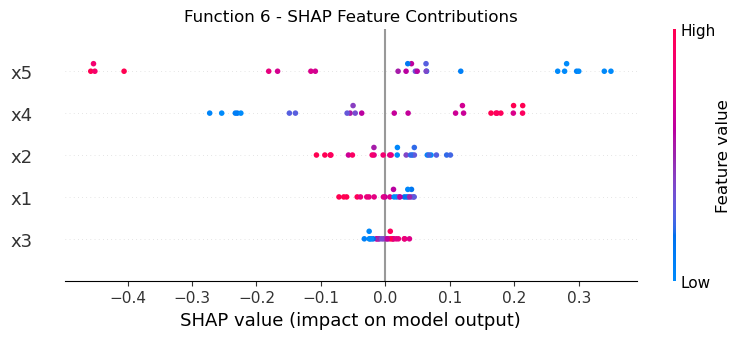

In [43]:
# Step 4: SHAP interpretability for the Random Forest
# ------------------------------------------------------------------
# Why SHAP over partial dependence here: with 5 correlated recipe ingredients, 
#    SHAP's TreeExplainer gives an exact, per-observation breakdown of how much each input pushed 
#    the prediction up or down, which scales better to more dimensions than 
#    a grid of partial-dependence plots and also shows the spread/direction of each feature's effect,

explainer   = shap.TreeExplainer(rf_F6)
shap_values = explainer.shap_values(all_inputs_F6)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs_F6,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions')
plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 7

In [44]:
# =============================================================================
# Function 7, Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates
# W6: RF (importance) → ARD GP; Importance-driven subspace narrowing; UCB, multi-start L-BFGS-B

# change: Isolate the dominant parameter subspace using ensemble filtering 
#         before running a GP, but relies on a thin ~10-sample window

print("\n" + "=" * 60)
print("Function 7 - Week 7")
print("=" * 60)
# Step 0: Load the initial dataset and append prior weekly queries
f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903	, 0.399853, 0.082758, 0.249752, 0.923732],   # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
    [0.020000, 0.084621, 0.685565, 0.148317, 0.347709, 0.669559],    # W6
])
prev_outputs_F7 = np.array([0.59279, 2.59480, 1.08804, 1.31103, 2.130313])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])

# Why log1p is precomputed here (log_outputs_F7) even though it's mostly used later: 
# keeping it alongside the raw values from the start makes it easy to switch 
# models between raw- and log-scale targets without recomputing

log_outputs_F7 = np.log1p(all_outputs_F7)

print(f"Total points: {len(all_outputs_F7)}, best (max): {all_outputs_F7.max():.4f}")


Function 7 - Week 7
Total points: 35, best (max): 2.5948


### Step 1a: Full-dataset RF (for HP1 bounds -- HP1 is the dominant split)

In [45]:
# Why: with 6 input dimensions and only ~35 points, searching the full space is inefficient. 
#    The plan (Steps 1a-1c) is to first find which dimension dominates the response, 
#    then look "underneath" that dominant dimension to see what else matters,
#    and finally combine both views into a reduced subspace that Step 2-3 will search more intensively.

feature_names = [f"HP{i+1}" for i in range(6)]

print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs_F7, all_outputs_F7);


Step 1a: Full-dataset Random Forest


In [46]:
# Why: reading off feature_importances_ from the full-dataset RF identifies
#     which of the 6 hyperparameters (HP1-HP6) explains most of the variance in the output -- 
#     this is expected to be HP1 based on prior weeks' analysis.
print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")


Full-dataset RF importance:
  HP1: 0.770
  HP2: 0.043
  HP3: 0.042
  HP4: 0.016
  HP5: 0.055
  HP6: 0.074


### Step 1b: Filtered RF (HP1 < 0.1 subset)

In [47]:
# Why filter to HP1 < 0.1: once a dominant dimension (HP1) is identified,
#    fitting a second RF only on points where HP1 is already small isolates
#    the effect of the *remaining* 5 dimensions within that promising region --
#    otherwise their influence would be masked by HP1's much larger effect.

print("\nStep 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)")
hp1_mask = all_inputs_F7[:, 0] < 0.1
filtered_inputs  = all_inputs_F7[hp1_mask]
filtered_outputs = all_outputs_F7[hp1_mask]

print(f"Points with HP1 < 0.1: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")


Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 9
Output range in subset: 0.008 to 2.595


In [48]:
# Why compare importances: fitting a fresh RF only on the HP1<0.1 subset and
#    comparing its feature importances against the full-dataset RF's shows
#    which dimensions become more (or less) influential once HP1's dominant effect is 
#     controlled for -- flagged with *** when the shift exceeds 0.1.#
rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}") 


Filtered RF importance:
  HP1: 0.402  (was 0.770 in full dataset) ***
  HP2: 0.128  (was 0.043 in full dataset) 
  HP3: 0.075  (was 0.042 in full dataset) 
  HP4: 0.132  (was 0.016 in full dataset) ***
  HP5: 0.066  (was 0.055 in full dataset) 
  HP6: 0.198  (was 0.074 in full dataset) ***


In [49]:
# Why SHAP on top of RF importance: feature_importances_ only ranks  magnitude, not direction. 
#     SHAP values show both how much and in which direction (positive/negative mean SHAP)
#     each dimension pushes predictions within the filtered subset, 
#     which Step 1c below uses to decide whether to push each dimension's search bounds high or low.

explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")


SHAP analysis (filtered RF, diagnostic):
  Feature    |SHAP|  Mean SHAP
  HP1         0.315     -0.002
  HP2         0.078     -0.018
  HP3         0.081     +0.020
  HP4         0.063     +0.003
  HP5         0.042     +0.019
  HP6         0.165     +0.046


### Step 1c: Combine full-dataset and filtered-dataset signals

In [50]:
# Step 1c: Combine full-dataset and filtered-dataset signals into one importance/direction view
# ------------------------------------------------------------------
# Why combine rather than pick one: HP1 and HP6's importance/direction are read from the FULL dataset
#    (they weren't the focus of the HP1<0.1 filter, and HP1 itself defined that filter
#    so its own within-subset importance would be uninformative). 
# HP2-HP5's importance/direction are read from the FILTERED subset, 
#     where their true effect (previously masked by HP1) is visible. 
# "push_high" is decided by checking whether top-25%-performing  points have 
#     a higher-than-average value for that dimension -- if so, 
#    the search should be pushed toward the high end of that dimension, and vice versa.

importance_combined = np.zeros(6)
importance_combined[0]   = rf_full.feature_importances_[0]
importance_combined[1:5] = rf_filtered.feature_importances_[1:5]
importance_combined[5]   = rf_full.feature_importances_[5]

top_mask_full = all_outputs_F7 >= np.percentile(all_outputs_F7, 75)
top_mean_full = all_inputs_F7[top_mask_full].mean(axis=0)
dataset_mean_full = all_inputs_F7.mean(axis=0)

top_mask_filt = filtered_outputs >= np.percentile(filtered_outputs, 75)
top_mean_filt = filtered_inputs[top_mask_filt].mean(axis=0)
subset_mean_filt = filtered_inputs.mean(axis=0)

push_high = np.zeros(6, dtype=bool)
push_high[0]   = top_mean_full[0] > dataset_mean_full[0]
push_high[1:5] = top_mean_filt[1:5] > subset_mean_filt[1:5]
push_high[5]   = top_mean_full[5] > dataset_mean_full[5]

print("\nDirectional signals (top-performers comparison):")
print(f"  {'Feature':<8} {'Source':<12} {'Top mean':>10} {'Avg mean':>10} {'Direction':>10}")

for i, name in enumerate(feature_names):
    if i == 0 or i == 5:
        print(f"  {name:<8} {'full':<12} {top_mean_full[i]:>10.3f} {dataset_mean_full[i]:>10.3f} {'HIGH' if push_high[i] else 'LOW':>10}")
    else:
        print(f"  {name:<8} {'filtered':<12} {top_mean_filt[i]:>10.3f} {subset_mean_filt[i]:>10.3f} {'HIGH' if push_high[i] else 'LOW':>10}")


Directional signals (top-performers comparison):
  Feature  Source         Top mean   Avg mean  Direction
  HP1      full              0.171      0.443        LOW
  HP2      filtered          0.269      0.386        LOW
  HP3      filtered          0.471      0.484        LOW
  HP4      filtered          0.205      0.405        LOW
  HP5      filtered          0.378      0.435        LOW
  HP6      full              0.762      0.532       HIGH


### Step 2: Subspace bounds from combined importance + top-performers direction

In [51]:
# Why constraint_width = 1 - importance: dimensions the model considers more important get 
#    a NARROWER allowed range (more tightly constrained around the favoured end), 
#    while less important dimensions are left with a wider  range since I have less confidence about 
#    where their optimum lies.
# push_high decides which end of that narrow/wide range to anchor to.

print("\nStep 2: Subspace Definition (combined full + filtered RF)")

constraint_width = 1.0 - importance_combined

subspace_lower = np.where(push_high, 1.0 - constraint_width, 0.02)
subspace_upper = np.where(push_high, 1.0, constraint_width)

subspace_lower = np.clip(subspace_lower, 0, 1)
subspace_upper = np.clip(subspace_upper, 0, 1)

print("\nSubspace bounds:")
for i, name in enumerate(feature_names):
    source = "full RF" if i == 0 or i == 5 else "filtered RF"
    label = "push HIGH" if push_high[i] else "push LOW"
    print(f"  {name}: [{subspace_lower[i]:.3f}, {subspace_upper[i]:.3f}]  ({source}, {label})")

print("\nStep 3: GP with UCB (candidate-based search)") 


Step 2: Subspace Definition (combined full + filtered RF)

Subspace bounds:
  HP1: [0.020, 0.230]  (full RF, push LOW)
  HP2: [0.020, 0.872]  (filtered RF, push LOW)
  HP3: [0.020, 0.925]  (filtered RF, push LOW)
  HP4: [0.020, 0.868]  (filtered RF, push LOW)
  HP5: [0.020, 0.934]  (filtered RF, push LOW)
  HP6: [0.074, 1.000]  (full RF, push HIGH)

Step 3: GP with UCB (candidate-based search)


### Step 3: GP surrogate + UCB search restricted to the subspace

In [52]:
# Step 3: Fit a GP surrogate on log-transformed outputs
# ------------------------------------------------------------------
# Why log1p: keeps the GP well-behaved if outputs are right-skewed/positive,
#    consistent with the log_outputs_F7 prepared back in Step 0.

kernel_F7 = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp_F7 = GaussianProcessRegressor(
    kernel=kernel_F7,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp_F7.fit(all_inputs_F7, np.log1p(all_outputs_F7));

In [53]:
# Step 3 (continued): sample candidates ONLY within the Step 2 subspace, then apply UCB
# ------------------------------------------------------------------
# Why restrict candidates to [subspace_lower, subspace_upper]: 
#   this is the key difference from the other functions' full-space [0,1] search --
#   by only generating candidates inside the data-driven subspace,  
#  the search  concentrates its 50,000 samples on the region where evidence 
#  (from Steps 1a-1c) suggests the optimum lives, 
#  rather than spreading them thinly across the whole 6D cube.

print("=" * 60)
print("Function 7 - Week 7")
print("=" * 60)

np.random.seed(42)
n_candidates = 50000
candidates_F7 = np.zeros((n_candidates, 6))
for dim in range(6):
    candidates_F7[:, dim] = np.random.uniform(subspace_lower[dim], subspace_upper[dim], n_candidates)

kappa_F7 = 2.0
mu_F7, sigma_F7 = gp_F7.predict(candidates_F7, return_std=True)
ucb_F7 = mu_F7 + kappa_F7 * sigma_F7

best_idx_F7 = np.argmax(ucb_F7)
best_candidate_F7 = candidates_F7[best_idx_F7]

predicted_mean, predicted_std = gp_F7.predict(best_candidate_F7.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean[0])

print(f"\nWeek 7 Query: {format_query(best_candidate_F7)}")
print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std[0]:.4f}")
print(f"UCB score (log scale):            {ucb_F7[best_idx_F7]:.4f}")


Function 7 - Week 7

Week 7 Query: 0.063339-0.124136-0.074385-0.373415-0.318790-0.765081

GP predicted Y (original scale) : 2.2058
GP uncertainty (log scale std)  : 0.1013
UCB score (log scale):            1.3675


### Step 4: Diagnostic plots

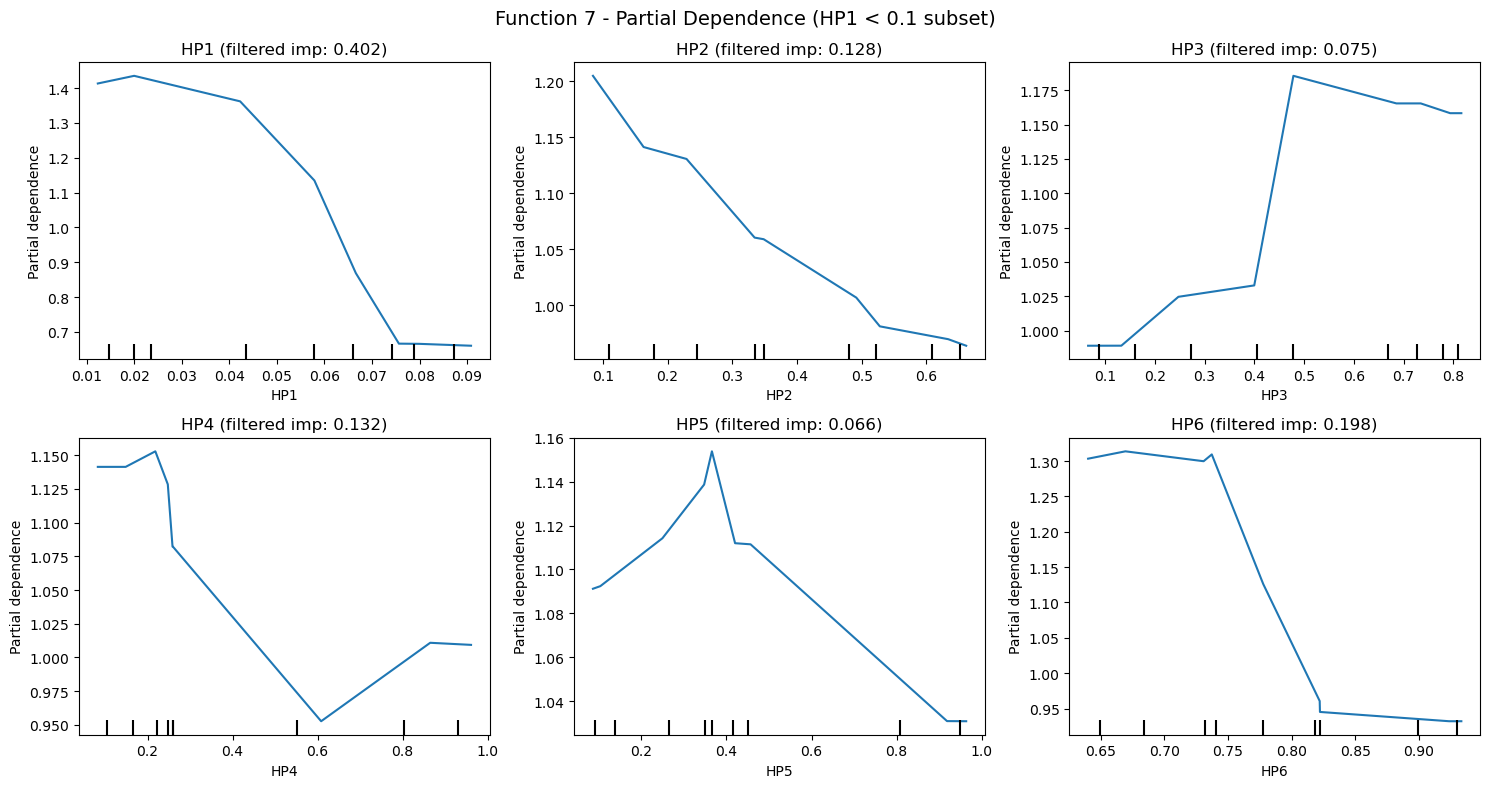

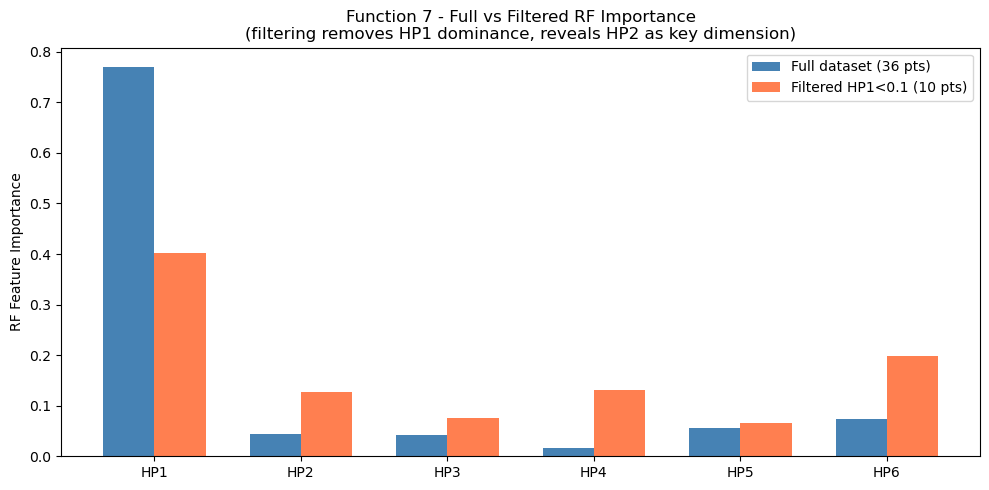

In [54]:
# Step 4: Diagnostic plots -- partial dependence in the filtered subset, and full-vs-filtered importance comparison
# ------------------------------------------------------------------
# Why: the top row of plots shows how the response depends on 
#   each dimension within the HP1<0.1 filtered subset (where their real effects are visible); 
#   the bar chart underneath makes the importance shift between the full-dataset RF
#   and the filtered RF explicit, visually justifying why
#   the subspace bounds in Step 2 were set the way they were.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
    
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset (36 pts)', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 (10 pts)', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# Function 8, Unspecified field, 8D array, 40 original samples - Week 7

#### Step 1: Load data & combine with weekly history

In [55]:
# =============================================================================
# Function 8, Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)
# W6: Dropout MLP (8→24→24→1); Standard scaling; UCB via MC-dropout uncertainty

## change: Guide candidate generation using SHAP feature attributions, 
#         though small background sample sizes leave multi-dimensional importance estimates shaky.

print("\n" + "=" * 60)
print("Function 8 - Week 7")
print("=" * 60)

# Why torch here specifically: with 8 input dimensions, tree ensembles and
#    GPs both start to struggle (GPs scale poorly with dimensionality, RF splits get sparse); 
#    a small neural network with MC-Dropout is used instead as a surrogate 
#    that can capture higher-dimensional interactions
#    while still producing an uncertainty estimate (via dropout at inference).
import torch
import torch.nn as nn

# Step 1: Load the initial dataset and append prior weekly queries
f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],    #W6
])
prev_outputs_F8 = np.array([8.26488, 7.35099, 9.76008, 8.590830, 9.619999])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 7
Total points: 45, best: 9.7601


#### Step 2: Scale data & define the MC-Dropout network

In [56]:
# Step 2: Scale the data and define the MC-Dropout network architecture
# ------------------------------------------------------------------
# Why StandardScaler on both X and Y: neural nets train far more reliably
#    when inputs/outputs are zero-mean, unit-variance -- otherwise gradients can be dominated by 
#   whichever raw dimension happens to have the largest scale.

# Why Dropout layers specifically (not just for regularisation): 
#     dropout is kept ACTIVE at prediction time (see mc_predict in the Step 0 helpers) 
#     so that running the same input through the network repeatedly yields
#     a distribution of predictions -- this is what gives the model an uncertainty estimate,
#    playing the same role sigma does for the GP/RF surrogates in other sections.

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

#### Step 3: Leave-one-out calibration check

In [57]:
# Step 3: Leave-One-Out (LOO) calibration check
# ------------------------------------------------------------------
# Why LOO: this is the closest thing to a genuine held-out validation 
#     this notebook does for Function 8 -- for every one of the ~45 observations,
#     a fresh model is trained on all OTHER points and tested on the held-out one.
# This produces an honest estimate of real prediction error (loo_errors)
#     alongside the model's own self-reported uncertainty (loo_sigmas), 
#    which Step 4 uses to check whether the network's uncertainty estimates are
#    actually trustworthy (well-calibrated) or need correcting.
loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    # re-fit scalers on the training fold only, to avoid leaking the held-out point's scale into training
    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.2)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=50)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

#### Step 4: Report calibration & train the final model

In [58]:
# Step 4: Report calibration, derive a suggested kappa, and train the final model on all data
# ------------------------------------------------------------------
# Why the error/sigma ratio matters: if mean |error| roughly equals mean sigma, 
#     the model's uncertainty is well-calibrated (ratio ~ 1.0). 
# A ratio above 1 means the model is under-confident about its own error and 
#    kappa should arguably be scaled up (as computed in "suggested kappa") so 
#    UCB exploration accounts for the true, larger uncertainty -- 
#     though the fixed kappa=1.7 below is what actually gets used going forward.
# Why retrain on the full dataset: the LOO loop above was purely diagnostic
#    (each fold dropped one point); the model actually used for Week 7's query
#    needs to see every available observation, so it's retrained here 
#    on the complete all_inputs_F8 / all_outputs_F8.

kappa = 1.7

print(f"\nLOO Calibration (true torch model):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {loo_errors.mean() / loo_sigmas.mean():.3f}  (1.0 = perfect calibration)")
print(f"  suggested kappa:     {kappa * (loo_errors.mean() / loo_sigmas.mean()):.2f}")


# train final model -- same as W6
torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.2)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()

print(f"Training loss (final): {loss.item():.4f}")


LOO Calibration (true torch model):
  mean |error|:        0.3155
  std  |error|:        0.3114
  max  |error|:        1.2293
  mean sigma (LOO):    0.2540
  ratio (error/sigma): 1.242  (1.0 = perfect calibration)
  suggested kappa:     2.11
Training loss (final): 0.0510


#### Step 5: SHAP interpretability

  0%|          | 0/45 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_33496\236596623.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


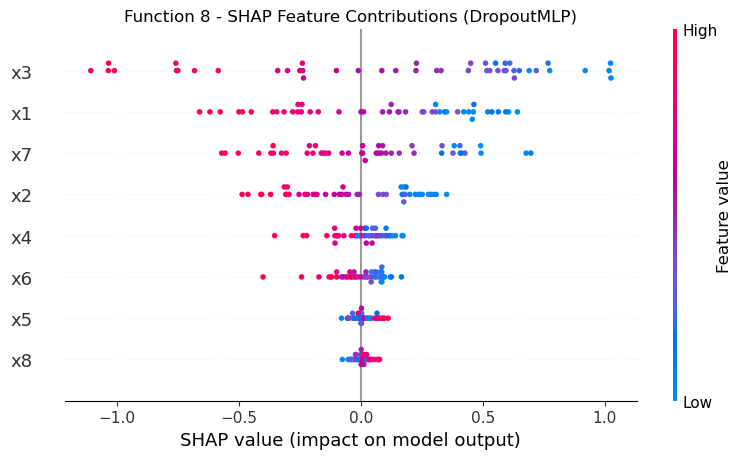

In [59]:
# Step 5: SHAP explainability for the trained neural network
# ------------------------------------------------------------------
# Why model.eval() first: SHAP needs deterministic predictions to attribute a stable value to each feature,
#   so dropout is switched off here (eval mode) purely for computing SHAP values -- 
#    this is the opposite mode to mc_predict, which needs dropout ON.
# Why KernelExplainer with a small background set: unlike TreeExplainer (used for the RF surrogates), 
#   a generic neural net has no exact SHAP algorithm, 
#    so KernelExplainer approximates SHAP values by perturbing inputs against 
#    a small "background" reference sample (20 points here) --
#     this is why the resulting importance estimates carry 
#     more approximation error than the tree-based ones elsewhere in the notebook.

model.eval()  

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()

In [60]:
# Step 5 (continued): switch the model back to train() mode
# ------------------------------------------------------------------
# Why: SHAP needed eval() mode for deterministic predictions; 
#     now that it's done, the model is flipped back to train() mode, 
#     so dropout is active again for the MC-Dropout acquisition step (Step 7) that follows.

model.train()  

DropoutMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=24, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=24, out_features=24, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=24, out_features=1, bias=True)
  )
)

#### Step 6: Build SHAP-informed candidate pool

In [61]:
# Step 6: Build a SHAP-informed local candidate pool plus a global LHS pool
# ------------------------------------------------------------------
# Why scale perturbation noise by SHAP importance: dimensions SHAP found more influential 
#    get proportionally MORE exploratory noise (0.02 to 0.10 range) around 
#    the top-performing points, so the local search probes more aggressively along the axes 
#    that matter most, while less important dimensions are perturbed only slightly.
# Why seed candidates from the top-3 points (not just the single best): 
#    this spreads the local search across multiple promising regions rather than
#     over-committing to one point, reducing the risk of getting stuck near a single local optimum.
# Why also add a global LHS pool: guards against the local, SHAP-weighted
#    search missing a completely different, unexplored region of the 8D space.

shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()  # normalise to [0, 1]

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}  (noise scale: {0.02 + 0.08 * shap_importance[i]:.3f})")

top_k = 3
best_idx_top = np.argsort(all_outputs_F8)[-top_k:]
best_points = all_inputs_F8[best_idx_top]

print(f"\nTop {top_k} points used for local search:")
for i, idx in enumerate(best_idx_top):
    print(f"  {all_inputs_F8[idx]} -> output: {all_outputs_F8[idx]:.4f}")

np.random.seed(42)
local_pool = []
for p in best_points:
    noise = np.random.randn(10000, 8)
    for dim in range(8):
        noise[:, dim] *= 0.02 + 0.08 * shap_importance[dim]
    samples = np.clip(p + noise, 0, 1)
    local_pool.append(samples)

local_pool = np.vstack(local_pool)

global_pool = LatinHypercube(d=8, seed=7).random(n=20000)  # different seed from W6

pool = np.vstack([local_pool, global_pool])
print(f"\nCandidate pool: {len(local_pool)} local + {len(global_pool)} global = {len(pool)} total")


SHAP-derived importance (normalised):
  x1: 0.604  (noise scale: 0.068)
  x2: 0.381  (noise scale: 0.050)
  x3: 1.000  (noise scale: 0.100)
  x4: 0.144  (noise scale: 0.032)
  x5: 0.058  (noise scale: 0.025)
  x6: 0.141  (noise scale: 0.031)
  x7: 0.469  (noise scale: 0.057)
  x8: 0.048  (noise scale: 0.024)

Top 3 points used for local search:
  [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
 0.48830701 0.89308498] -> output: 9.5985
  [0.060495 0.02709  0.006185 0.132068 0.160719 0.354431 0.001361 0.931902] -> output: 9.6200
  [0.035148 0.       0.018976 0.       0.999999 0.361194 0.00731  0.      ] -> output: 9.7601

Candidate pool: 30000 local + 20000 global = 50000 total


#### Step 7: Propose the Week 7 query (MC-Dropout UCB)

In [62]:
# Step 7: Score the candidate pool with MC-Dropout UCB and select the Week 7 query
# ------------------------------------------------------------------
# Why mc_predict here: this is where the dropout-based uncertainty from Step 2's architecture
#      is actually put to use -- each candidate is passed through the network 50 times with dropout active, 
#      giving a mean (mu) and spread (sigma) per candidate, 
#      exactly analogous to the GP's predict(..., return_std=True) used elsewhere.
#  kappa=1.7 (from Step 4's calibration  check) then combines
#     the two into the same UCB formula used throughout the notebook.

print("=" * 60)
print("Function 8 - Week 7")
print("=" * 60)

pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=50)

mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]

# UCB with kappa=1.7
ucb_F8   = mu_F8 + kappa * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]

print(f"mu   range: {mu_F8.min():.3f} to {mu_F8.max():.3f}")
print(f"sigma range: {sigma_F8.min():.3f} to {sigma_F8.max():.3f}")
print(f"kappa*sigma range: {(kappa*sigma_F8).min():.3f} to {(kappa*sigma_F8).max():.3f}")

print(f"\nWeek 7 Query: {format_query(query_F8)}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")

Function 8 - Week 7
mu   range: 5.310 to 9.775
sigma range: 0.073 to 0.656
kappa*sigma range: 0.124 to 1.115

Week 7 Query: 0.000000-0.009147-0.046571-0.113147-0.150211-0.340739-0.038068-0.928497
MC mu: 9.6740, sigma: 0.4061
UCB:   10.3643
